###  Plot Array-Level Jaccard Similarity Map

This map shows each camera-trap array as a small circle, colored by array-level Jaccard similarity.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

OUTPUT_PATH = "../../outputs"
DATA_PATH = "../../data"
# Array-level comparison file
ARRAY_COMPARE_FILE = f"{OUTPUT_PATH}/array_level_ssusa_iucn_comparison.pkl"

# Load comparison results
array_compare = pd.read_pickle(ARRAY_COMPARE_FILE)

print("Shape:", array_compare.shape)
array_compare.head()

Shape: (256, 13)


,Camera_Trap_Array,observed_species,n_observed,predicted_species,n_predicted,jaccard,n_overlap,n_union,geometry,habitat,development_level,feature_type,unique_survey_nights
0,ARNWR,"{didelphis virginiana, canis latrans, sciurus ...",9,"{sciurus niger, didelphis virginiana, sciurus ...",13,0.692308,9,13,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",Wetland,Wild,Road dirt,115
1,AandM,"{didelphis virginiana, canis latrans, lepus ca...",10,"{didelphis virginiana, canis latrans, lepus ca...",16,0.529412,9,17,"POLYGON ((-143935.903 351080.803, -144033.92 3...",Forest,Rural,Road dirt,64
2,Abilene,"{sciurus niger, didelphis virginiana, lepus ca...",14,"{sciurus niger, didelphis virginiana, lepus ca...",18,0.600000,12,20,"POLYGON ((-365247.465 1024198.242, -365320.178...",Grassland,Rural,Trail game,376
3,AbitaFlats,"{canis latrans, sciurus carolinensis, dasypus ...",7,"{sciurus niger, didelphis virginiana, dasypus ...",14,0.400000,6,15,"POLYGON ((577236.305 843108.673, 577157.482 84...",Forest,Wild,NaN,86
4,Afognak,"{martes americana, cervus elaphus, ursus arcto...",6,{ursus arctos},1,0.166667,1,6,"MULTIPOLYGON (((-3376275.354 4909772.521, -337...",Forest,Wild,Road dirt,36


In [3]:
array_compare.columns

Index(['Camera_Trap_Array', 'observed_species', 'n_observed',
       'predicted_species', 'n_predicted', 'jaccard', 'n_overlap', 'n_union',
       'geometry', 'habitat', 'development_level', 'feature_type',
       'unique_survey_nights'],
      dtype='object')

### Create Array Centroid Points

In [4]:
# Convert the loaded table to a GeoDataFrame
array_gdf = gpd.GeoDataFrame(
    array_compare,
    geometry="geometry"
)

# Check CRS and geometry type
print("CRS:", array_gdf.crs)
print("Geometry types:")
print(array_gdf.geometry.geom_type.value_counts())

# Create point geometry from each dissolved array footprint
array_points = array_gdf.copy()
array_points["geometry"] = array_points.geometry.centroid

array_points[["Camera_Trap_Array", "jaccard", "geometry"]].head()

CRS: EPSG:5070
Geometry types:
Polygon         147
MultiPolygon    109
Name: count, dtype: int64


,Camera_Trap_Array,jaccard,geometry
0,ARNWR,0.692308,POINT (1786956.646 1609117.492)
1,AandM,0.529412,POINT (-143815.266 353082.619)
2,Abilene,0.600000,POINT (-364542.936 1025765.325)
3,AbitaFlats,0.400000,POINT (577424.625 844652.776)
4,Afognak,0.166667,POINT (-3377244.423 4910273.382)


### Convert Points to Latitude/Longitude

In [5]:
# Convert array centroid points to WGS84 latitude/longitude
# This is useful for plotting on a U.S. map

array_points_wgs = array_points.to_crs("EPSG:4326")

array_points_wgs["lon"] = array_points_wgs.geometry.x
array_points_wgs["lat"] = array_points_wgs.geometry.y

array_points_wgs[
    ["Camera_Trap_Array", "jaccard", "lon", "lat"]
].head()

,Camera_Trap_Array,jaccard,lon,lat
0,ARNWR,0.692308,-75.893935,35.827098
1,AandM,0.529412,-97.427163,26.220977
2,Abilene,0.600000,-99.888993,32.238004
3,AbitaFlats,0.400000,-89.967518,30.512857
4,Afognak,0.166667,-152.291115,58.287826


### Load U.S. Country Boundary

In [6]:
# Natural Earth country boundaries

COUNTRIES_FILE = (
    DATA_PATH +
    "/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
)

countries = gpd.read_file(COUNTRIES_FILE)

print("CRS:", countries.crs)
print("Countries:", len(countries))

countries.head()

CRS: EPSG:4326
Countries: 177


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


### Extract the United States polygon

In [7]:
usa = countries[
    countries["ADMIN"] == "United States of America"
].copy()

print("USA polygons:", len(usa))

usa[["ADMIN"]]

USA polygons: 1


,ADMIN
4,United States of America


In [8]:
print(usa.crs)
print(array_points_wgs.crs)

EPSG:4326
EPSG:4326


### Plot Array-Level Jaccard Similarity Map

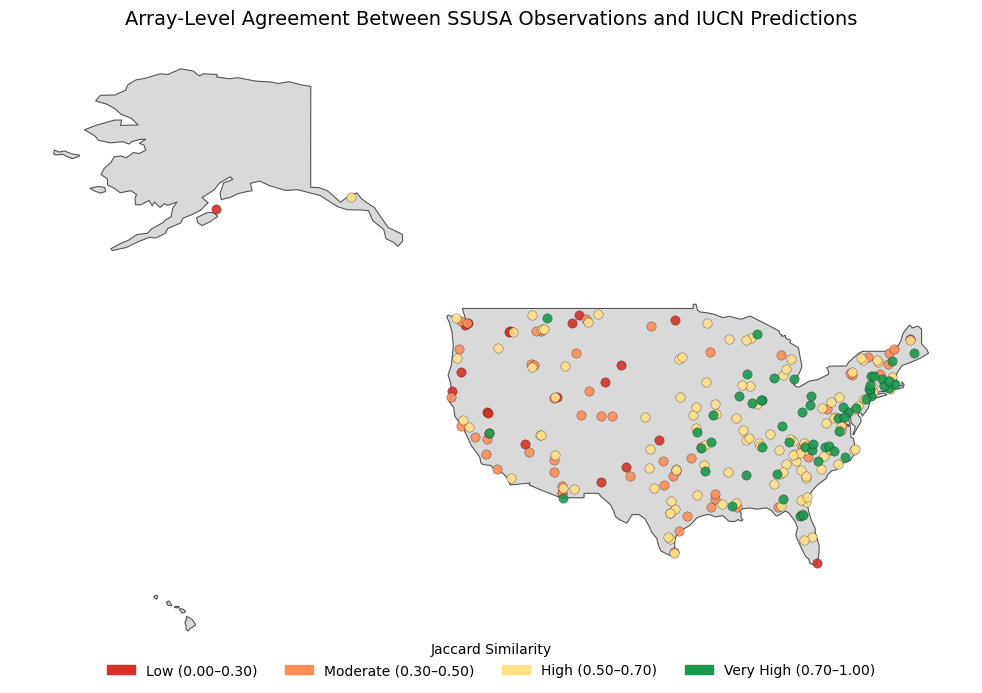

In [9]:
import pandas as pd
import matplotlib.patches as mpatches

# Create Jaccard categories
bins = [0.0, 0.3, 0.5, 0.7, 1.0]

labels = [
    "Low (0.00–0.30)",
    "Moderate (0.30–0.50)",
    "High (0.50–0.70)",
    "Very High (0.70–1.00)"
]

array_points_wgs["jaccard_class"] = pd.cut(
    array_points_wgs["jaccard"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Red → Orange → Yellow → Green
color_map = {
    "Low (0.00–0.30)": "#d73027",
    "Moderate (0.30–0.50)": "#fc8d59",
    "High (0.50–0.70)": "#fee08b",
    "Very High (0.70–1.00)": "#1a9850"
}

fig, ax = plt.subplots(figsize=(12, 7))

# US background
usa.plot(
    ax=ax,
    color="#d9d9d9",
    edgecolor="#555555",
    linewidth=0.8,
    zorder=1
)

# Plot each category separately
for category, color in color_map.items():

    subset = array_points_wgs[
        array_points_wgs["jaccard_class"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=45,
        edgecolor="black",
        linewidth=0.2,
        alpha=0.9,
        zorder=2
    )

# Horizontal legend
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_handles,
    title="Jaccard Similarity",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,                      # horizontal legend
    frameon=False
)

ax.set_title(
    "Array-Level Agreement Between SSUSA Observations and IUCN Predictions",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

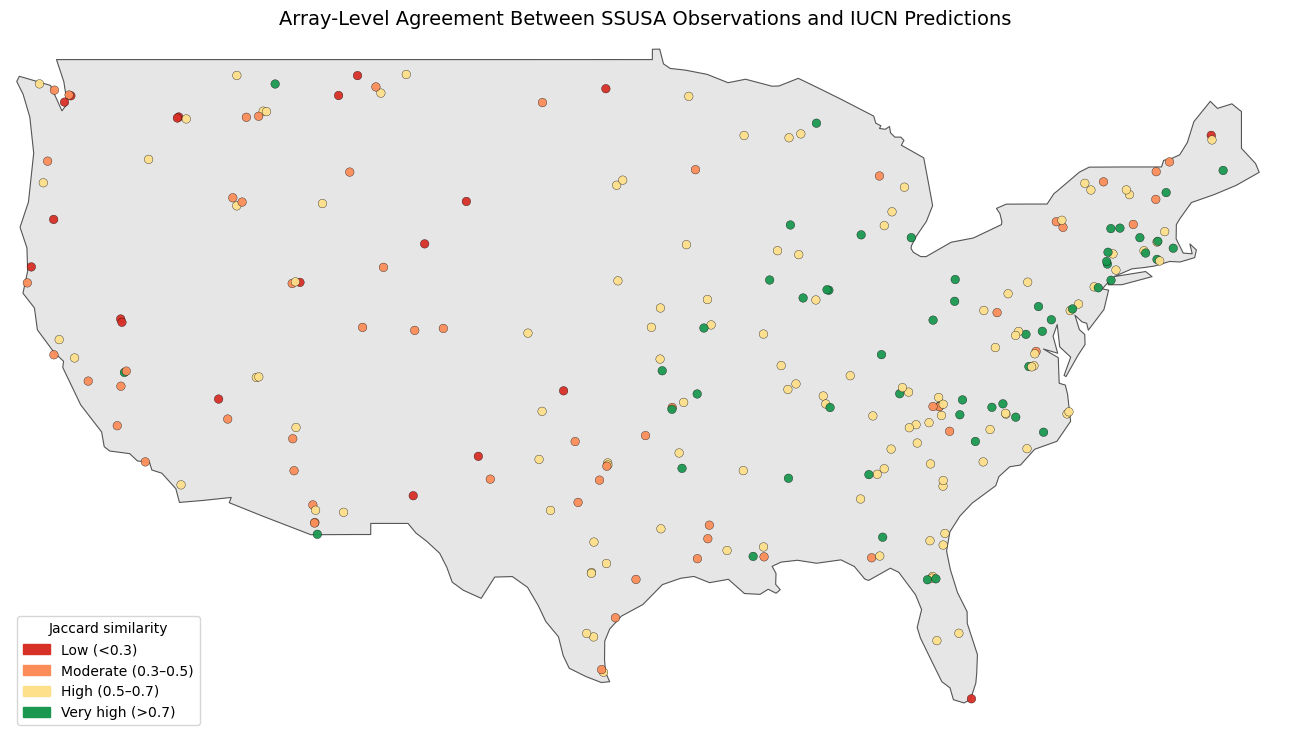

In [10]:
import matplotlib.patches as mpatches
import pandas as pd

# Keep mainland U.S. arrays only for cleaner map
array_mainland = array_points_wgs[
    (array_points_wgs["lon"] >= -125) &
    (array_points_wgs["lon"] <= -66) &
    (array_points_wgs["lat"] >= 24) &
    (array_points_wgs["lat"] <= 50)
].copy()

# Create Jaccard categories
bins = [0, 0.3, 0.5, 0.7, 1.0]
labels = [
    "Low (<0.3)",
    "Moderate (0.3–0.5)",
    "High (0.5–0.7)",
    "Very high (>0.7)"
]

array_mainland["jaccard_class"] = pd.cut(
    array_mainland["jaccard"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Color palette
color_map = {
    "Low (<0.3)": "#d73027",
    "Moderate (0.3–0.5)": "#fc8d59",
    "High (0.5–0.7)": "#fee08b",
    "Very high (>0.7)": "#1a9850"
}

array_mainland["plot_color"] = array_mainland["jaccard_class"].map(color_map)

fig, ax = plt.subplots(figsize=(13, 8))

# Mainland U.S. background
usa.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#555555",
    linewidth=0.8,
    zorder=1
)

# Plot array points
array_mainland.plot(
    ax=ax,
    color=array_mainland["plot_color"],
    markersize=38,
    edgecolor="black",
    linewidth=0.25,
    alpha=0.95,
    zorder=2
)

# Zoom to mainland U.S.
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

# Manual legend
legend_handles = [
    mpatches.Patch(color=color_map[label], label=label)
    for label in labels
]

ax.legend(
    handles=legend_handles,
    title="Jaccard similarity",
    loc="lower left",
    frameon=True
)

ax.set_title(
    "Array-Level Agreement Between SSUSA Observations and IUCN Predictions",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [11]:
outside_mainland = array_points_wgs[
    (array_points_wgs["lon"] < -125) |
    (array_points_wgs["lon"] > -66) |
    (array_points_wgs["lat"] < 24) |
    (array_points_wgs["lat"] > 50)
]

outside_mainland[
    ["Camera_Trap_Array", "lon", "lat", "jaccard"]
]

,Camera_Trap_Array,lon,lat,jaccard
4,Afognak,-152.291115,58.287826,0.166667
62,Crupi,-136.121262,59.412128,0.642857


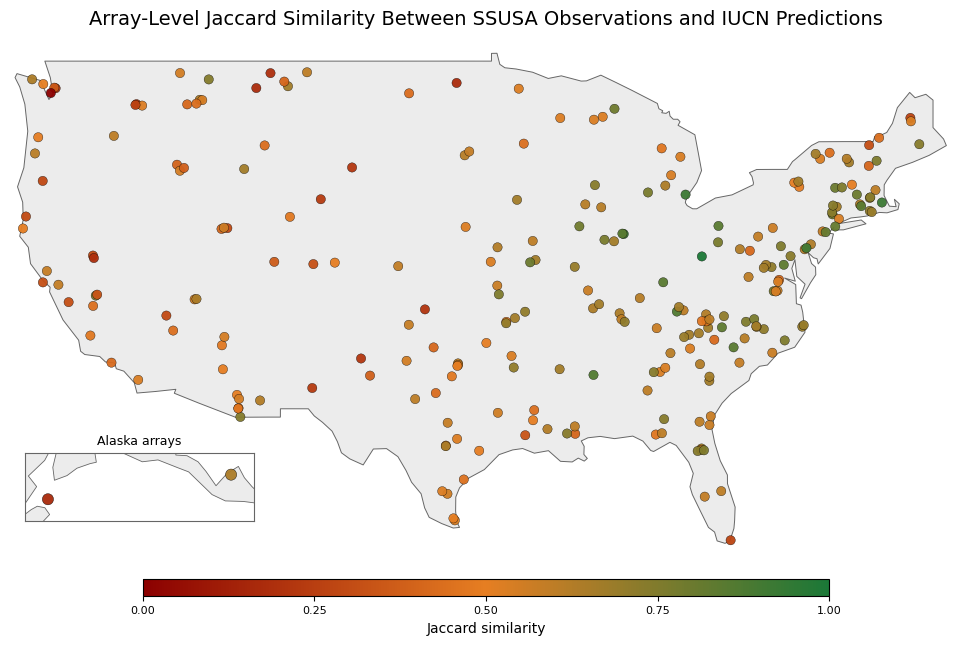

In [12]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Split mainland and Alaska arrays
# -----------------------------
mainland_arrays = array_points_wgs[
    (array_points_wgs["lon"] >= -125) &
    (array_points_wgs["lon"] <= -66) &
    (array_points_wgs["lat"] >= 24) &
    (array_points_wgs["lat"] <= 50)
].copy()

alaska_arrays = array_points_wgs[
    array_points_wgs["Camera_Trap_Array"].isin(["Afognak", "Crupi"])
].copy()

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 8))

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_jaccard",
    [
        "#8B0000",  # dark red
        "#E67E22",  # orange
        "#1B7837"   # dark green
    ]
)

cmap = custom_cmap
vmin, vmax = 0, 1

# -----------------------------
# Mainland U.S. background
# -----------------------------
usa.plot(
    ax=ax,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.7,
    zorder=1
)

# -----------------------------
# Mainland array points
# -----------------------------
mainland_arrays.plot(
    ax=ax,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=45,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    zorder=2
)

# Mainland map extent
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    "Array-Level Jaccard Similarity Between SSUSA Observations and IUCN Predictions",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# -----------------------------
# Alaska inset, cropped to two array locations
# -----------------------------
ax_ak = inset_axes(
    ax,
    width="24%",
    height="24%",
    loc="lower left",
    borderpad=1.1
)

usa.plot(
    ax=ax_ak,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.6,
    zorder=1
)

alaska_arrays.plot(
    ax=ax_ak,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=65,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.3,
    legend=False,
    zorder=2
)

# Tight crop around Alaska array points
xmin = alaska_arrays["lon"].min() - 2
xmax = alaska_arrays["lon"].max() + 2
ymin = alaska_arrays["lat"].min() - 1
ymax = alaska_arrays["lat"].max() + 1

ax_ak.set_xlim(xmin, xmax)
ax_ak.set_ylim(ymin, ymax)

ax_ak.set_title("Alaska arrays", fontsize=9)
ax_ak.set_xticks([])
ax_ak.set_yticks([])

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("#666666")

# -----------------------------
# Thin horizontal gradient colorbar
# -----------------------------
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.2,
    pad=0.02,
    shrink=0.55,
    aspect=40
)

cbar.set_label("Jaccard similarity", fontsize=10)
cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.92,
    bottom=0.08
)
plt.show()

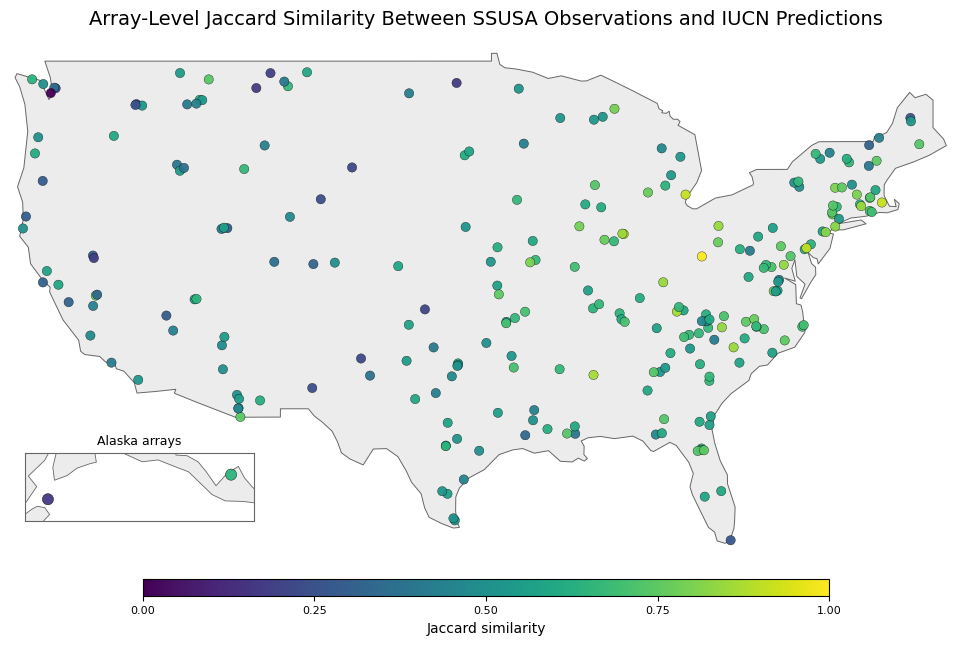

In [13]:


# --------------------------------------------------
# Split mainland and Alaska arrays
# --------------------------------------------------
mainland_arrays = array_points_wgs[
    (array_points_wgs["lon"] >= -125) &
    (array_points_wgs["lon"] <= -66) &
    (array_points_wgs["lat"] >= 24) &
    (array_points_wgs["lat"] <= 50)
].copy()

alaska_arrays = array_points_wgs[
    array_points_wgs["Camera_Trap_Array"].isin(["Afognak", "Crupi"])
].copy()

# --------------------------------------------------
# Figure setup
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8))

# Use Viridis colormap
cmap = plt.cm.viridis
vmin, vmax = 0, 1

# --------------------------------------------------
# Mainland U.S. background
# --------------------------------------------------
usa.plot(
    ax=ax,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.7,
    zorder=1
)

# --------------------------------------------------
# Mainland array points
# --------------------------------------------------
mainland_arrays.plot(
    ax=ax,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=45,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    zorder=2
)

# Mainland map extent
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    "Array-Level Jaccard Similarity Between SSUSA Observations and IUCN Predictions",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# --------------------------------------------------
# Alaska inset
# --------------------------------------------------
ax_ak = inset_axes(
    ax,
    width="24%",
    height="24%",
    loc="lower left",
    borderpad=1.1
)

usa.plot(
    ax=ax_ak,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.6,
    zorder=1
)

alaska_arrays.plot(
    ax=ax_ak,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=65,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.3,
    legend=False,
    zorder=2
)

# Tight crop around Alaska array points
xmin = alaska_arrays["lon"].min() - 2
xmax = alaska_arrays["lon"].max() + 2
ymin = alaska_arrays["lat"].min() - 1
ymax = alaska_arrays["lat"].max() + 1

ax_ak.set_xlim(xmin, xmax)
ax_ak.set_ylim(ymin, ymax)

ax_ak.set_title("Alaska arrays", fontsize=9)
ax_ak.set_xticks([])
ax_ak.set_yticks([])

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("#666666")

# --------------------------------------------------
# Horizontal colorbar
# --------------------------------------------------
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.2,
    pad=0.02,
    shrink=0.55,
    aspect=40
)

cbar.set_label("Jaccard similarity", fontsize=10)
cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.92,
    bottom=0.08
)

plt.show()

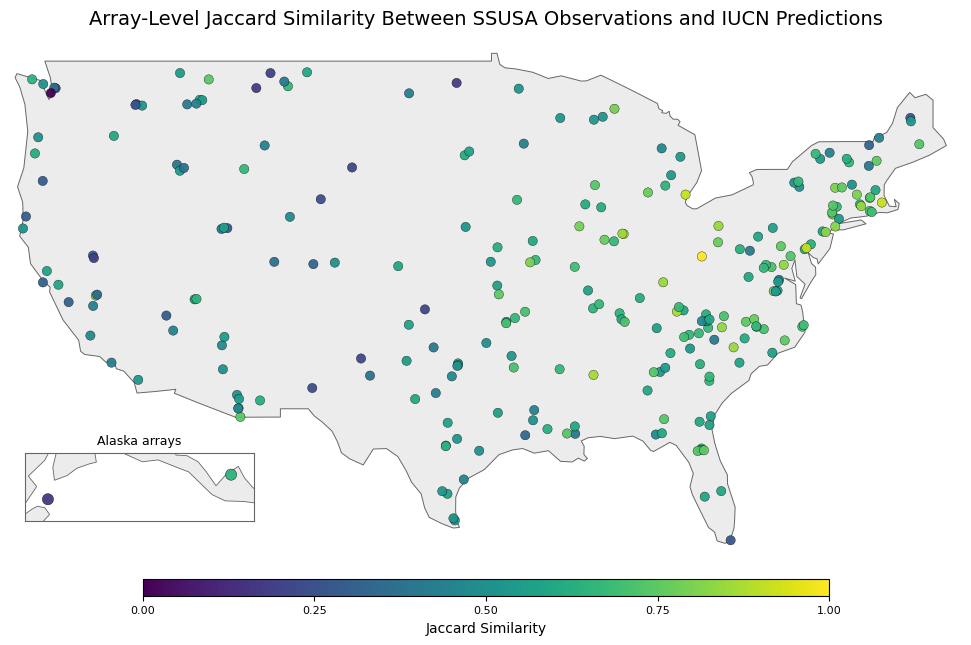

In [14]:


# -----------------------------
# Split mainland and Alaska arrays
# -----------------------------
mainland_arrays = array_points_wgs[
    (array_points_wgs["lon"] >= -125) &
    (array_points_wgs["lon"] <= -66) &
    (array_points_wgs["lat"] >= 24) &
    (array_points_wgs["lat"] <= 50)
].copy()

alaska_arrays = array_points_wgs[
    array_points_wgs["Camera_Trap_Array"].isin(["Afognak", "Crupi"])
].copy()

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 8))

# Use Viridis colormap
cmap = plt.cm.viridis
vmin, vmax = 0, 1

# -----------------------------
# Mainland U.S. background
# -----------------------------
usa.plot(
    ax=ax,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.7,
    zorder=1
)

# -----------------------------
# Mainland array points
# -----------------------------
mainland_arrays.plot(
    ax=ax,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=45,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    zorder=2
)

# Mainland map extent
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    "Array-Level Jaccard Similarity Between SSUSA Observations and IUCN Predictions",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# -----------------------------
# Alaska inset
# -----------------------------
ax_ak = inset_axes(
    ax,
    width="24%",
    height="24%",
    loc="lower left",
    borderpad=1.1
)

usa.plot(
    ax=ax_ak,
    color="#ececec",
    edgecolor="#666666",
    linewidth=0.6,
    zorder=1
)

alaska_arrays.plot(
    ax=ax_ak,
    column="jaccard",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=65,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.3,
    legend=False,
    zorder=2
)

# Tight crop around Alaska array points
xmin = alaska_arrays["lon"].min() - 2
xmax = alaska_arrays["lon"].max() + 2
ymin = alaska_arrays["lat"].min() - 1
ymax = alaska_arrays["lat"].max() + 1

ax_ak.set_xlim(xmin, xmax)
ax_ak.set_ylim(ymin, ymax)

ax_ak.set_title("Alaska arrays", fontsize=9)
ax_ak.set_xticks([])
ax_ak.set_yticks([])

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("#666666")

# -----------------------------
# Horizontal colorbar
# -----------------------------
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.20,
    pad=0.02,
    shrink=0.55,
    aspect=40
)

cbar.set_label("Jaccard Similarity", fontsize=10)
cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.92,
    bottom=0.08
)

plt.show()

In [19]:
# -----------------------------
# Keep only contiguous / mainland U.S. arrays
# -----------------------------
mainland_arrays = array_points_wgs[
    (array_points_wgs["lon"] >= -125) &
    (array_points_wgs["lon"] <= -66) &
    (array_points_wgs["lat"] >= 24) &
    (array_points_wgs["lat"] <= 50)
].copy()

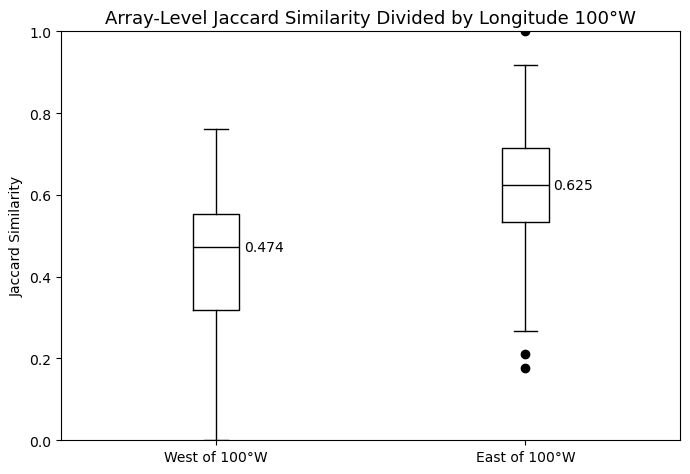

In [31]:



# -----------------------------
# Divide by 100°W longitude
# West: lon < -100
# East: lon >= -100
# -----------------------------
mainland_arrays["region_100W"] = mainland_arrays["lon"].apply(
    lambda x: "East of 100°W" if x >= -100 else "West of 100°W"
)

# Force West on the left and East on the right
region_order = ["West of 100°W", "East of 100°W"]

# Set region_100W as an ordered categorical variable before plotting
mainland_arrays["region_100W"] = pd.Categorical(
    mainland_arrays["region_100W"],
    categories=region_order,
    ordered=True
)

# -----------------------------
# Box plot comparison
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

bp = mainland_arrays.boxplot(
    column="jaccard",
    by="region_100W",
    ax=ax,
    grid=False,
    patch_artist=False,
    return_type="dict"
)

elements = bp["jaccard"]

# Box outline
for box in elements["boxes"]:
    box.set(color="black", linewidth=1)

# Whiskers
for whisker in elements["whiskers"]:
    whisker.set(color="black", linewidth=1)

# End caps
for cap in elements["caps"]:
    cap.set(color="black", linewidth=1)

# Median line
for median in elements["medians"]:
    median.set(color="black", linewidth=1)

# Outliers
for flier in elements["fliers"]:
    flier.set(markeredgecolor="black", markerfacecolor="black")

# Change median lines to same color as box outlines
for median in bp["jaccard"]["medians"]:
    median.set_color("#000000")   # same black as box outline
    median.set_linewidth(1)

# Compute medians
medians = mainland_arrays.groupby("region_100W", observed=False)["jaccard"].median()

# Annotate medians
for i, region in enumerate(region_order, start=1):
    m = medians.loc[region]

    ax.text(
        i + 0.09,
        m,
        f"{m:.3f}",
        color="#000000",
        fontsize=10,
        va="center"
    )

ax.set_title("Array-Level Jaccard Similarity Divided by Longitude 100°W", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Jaccard Similarity")
#plt.suptitle("")
ax.set_ylim(0, 1)
plt.suptitle("")
plt.tight_layout()
plt.show()